In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, root_mean_squared_error, r2_score
from sklearn.svm import SVC, SVR

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

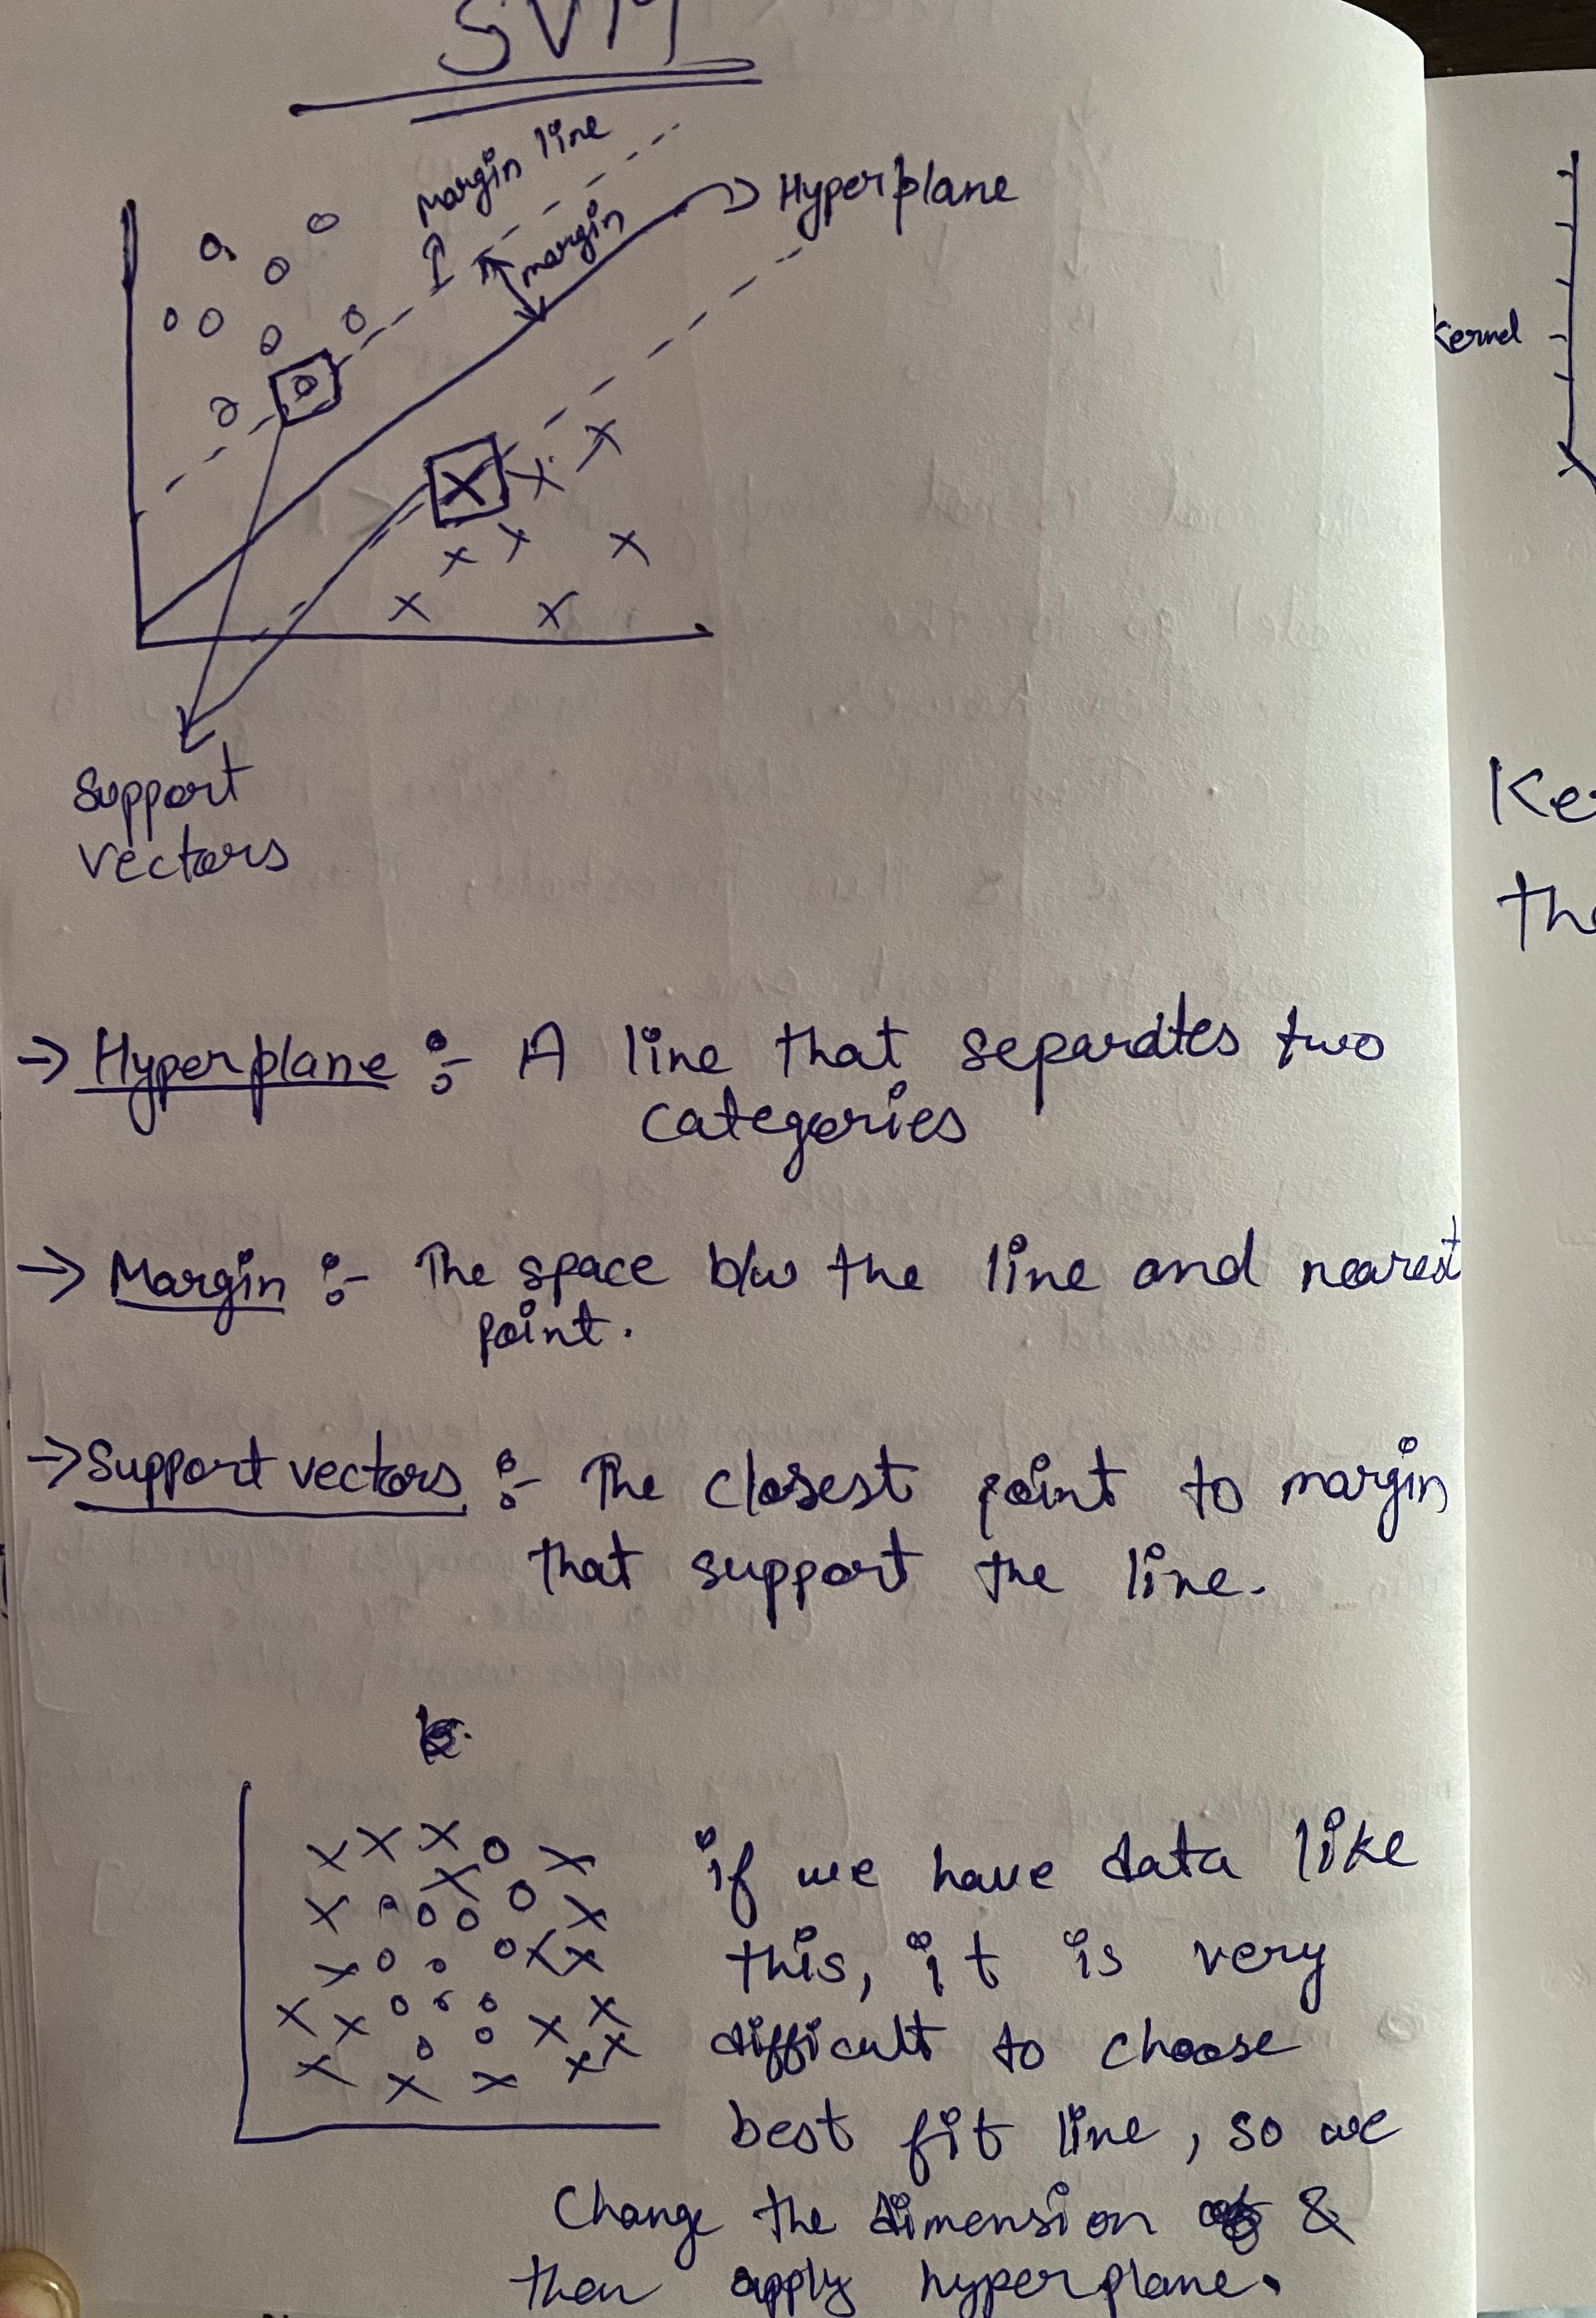
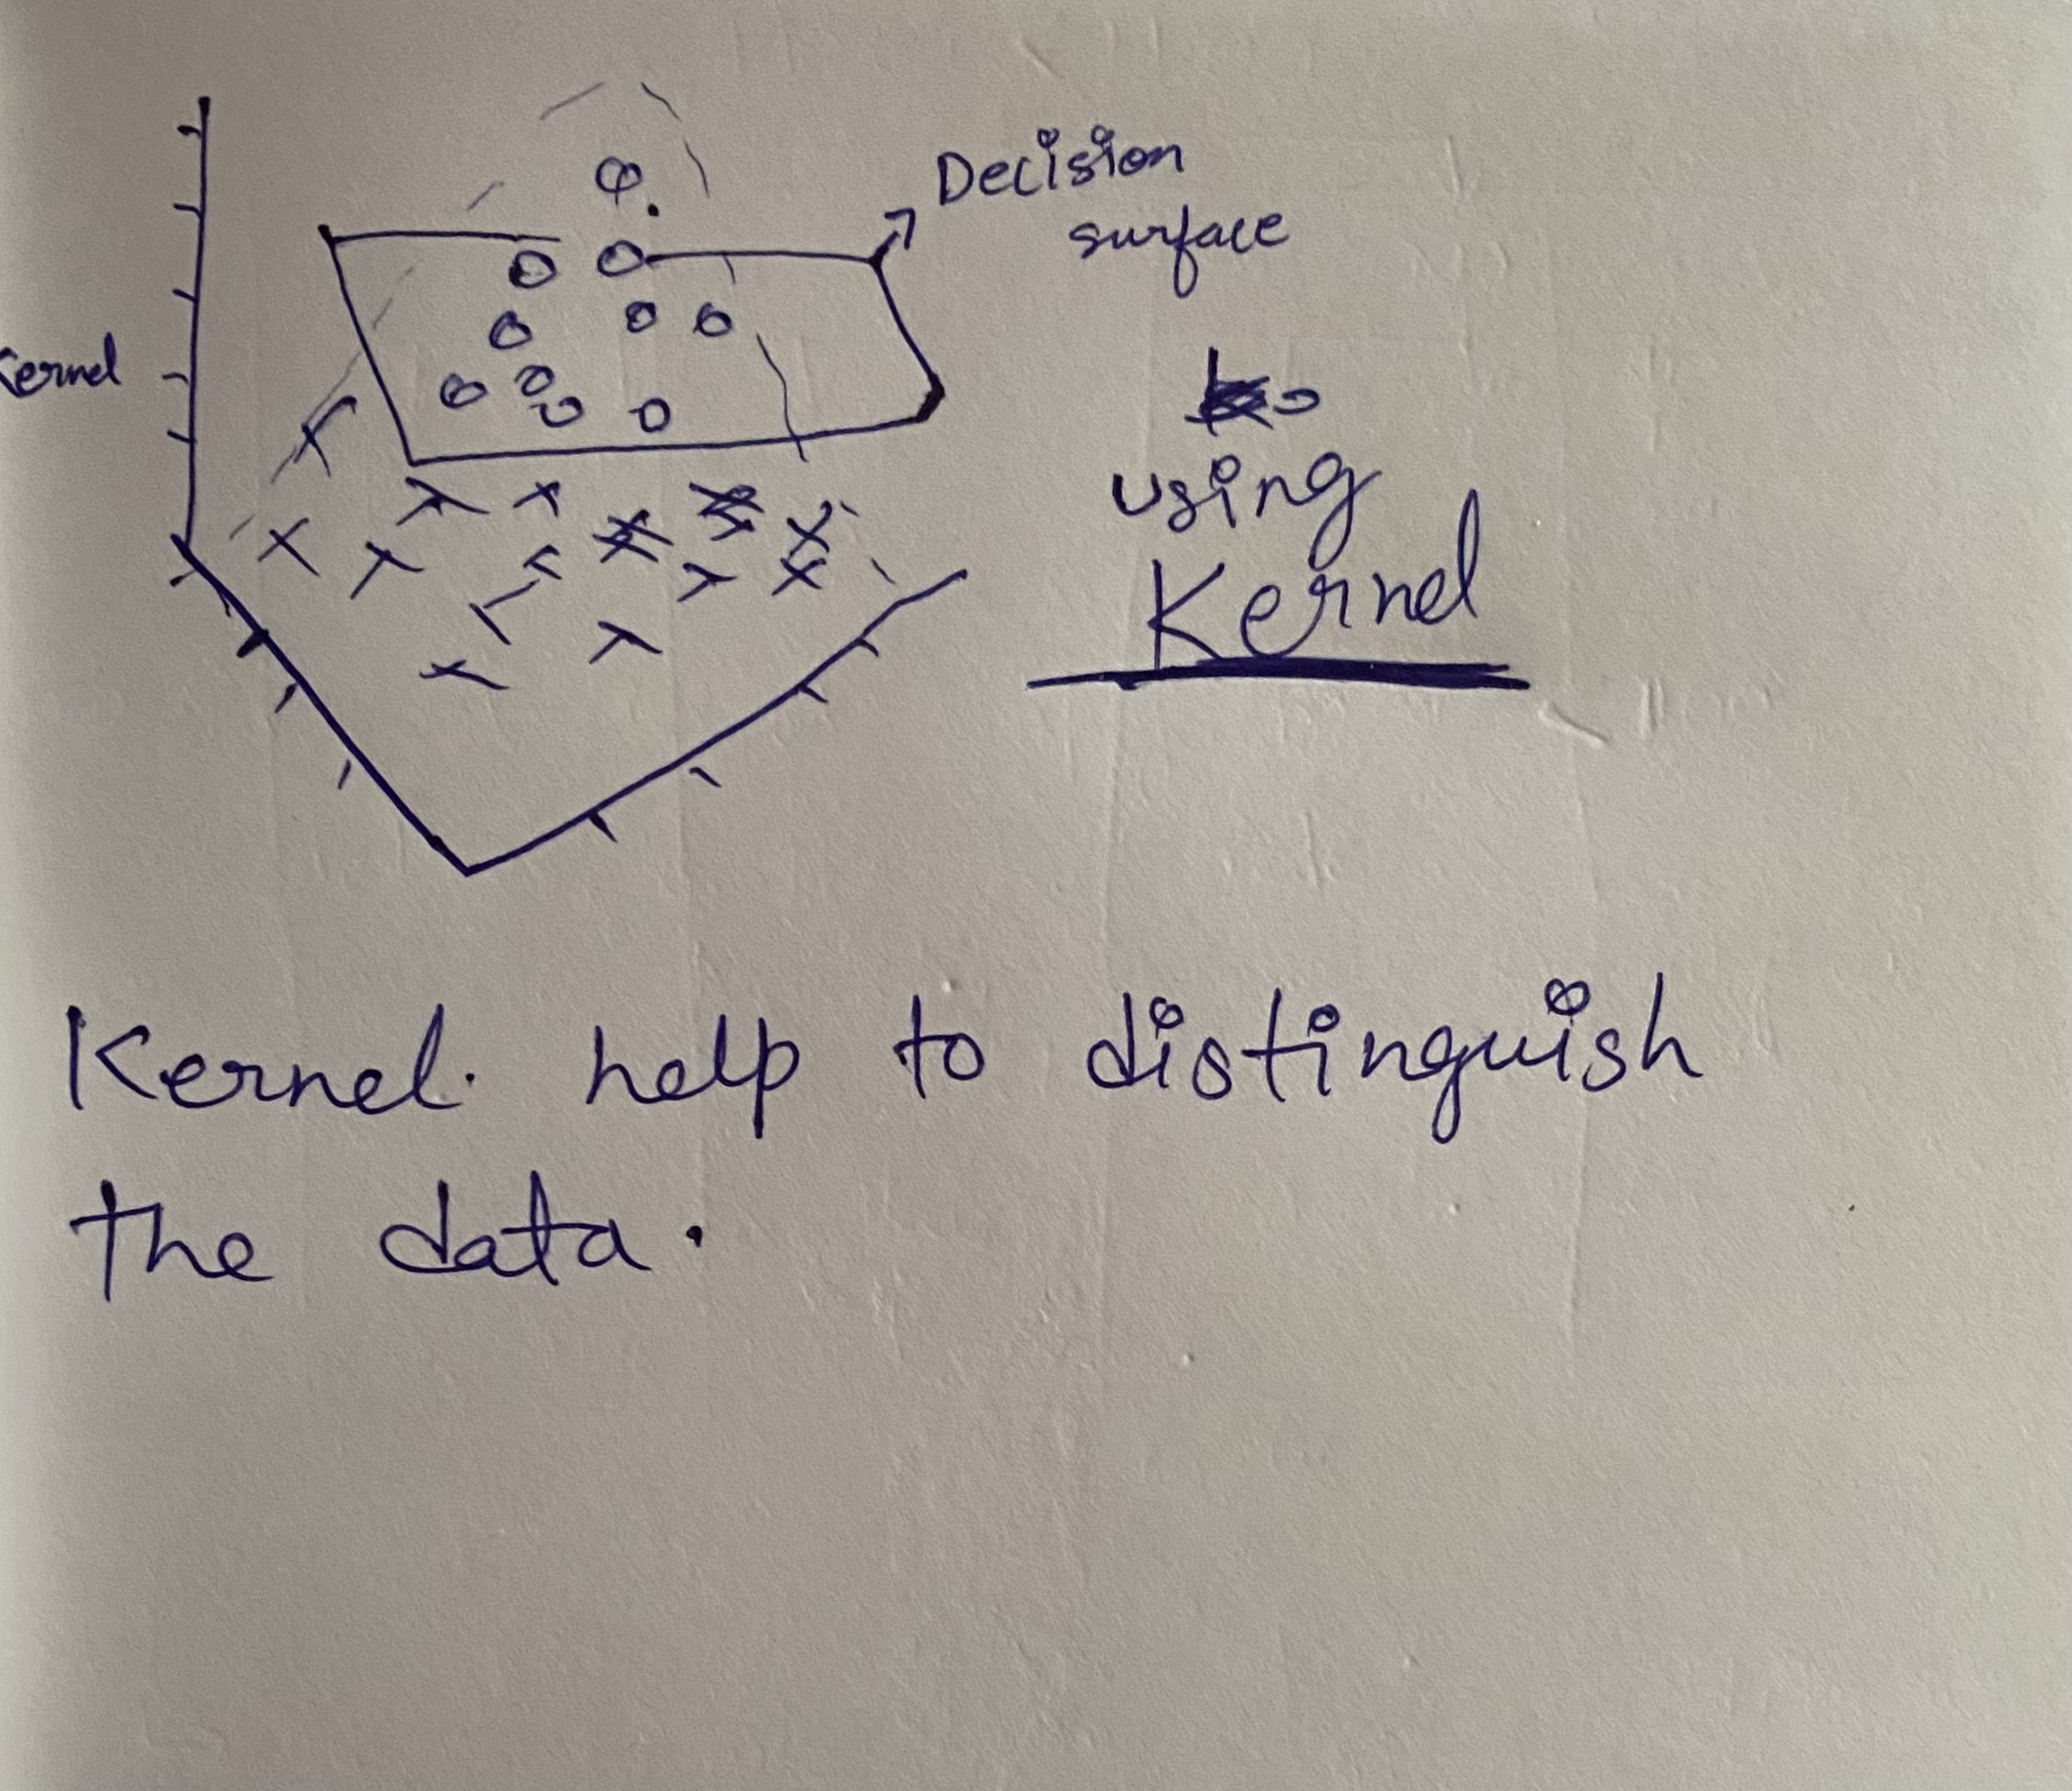

In [3]:
x = df.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'])

label = LabelEncoder()
x['Embarked'] = label.fit_transform(x['Embarked']) 
x['Sex'] = label.fit_transform(x['Sex'])

impute = SimpleImputer(strategy="median")
x = impute.fit_transform(x)

y = df['Survived']
scale = StandardScaler()
x = scale.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=76, test_size=0.2 )

In [4]:
model = SVC(kernel='rbf') # there are various parameters will learn about that through documentation
model.fit(x_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [6]:
y_pred = model.predict(x_test)

In [7]:
accuracy_score(y_test, y_pred)

0.8435754189944135

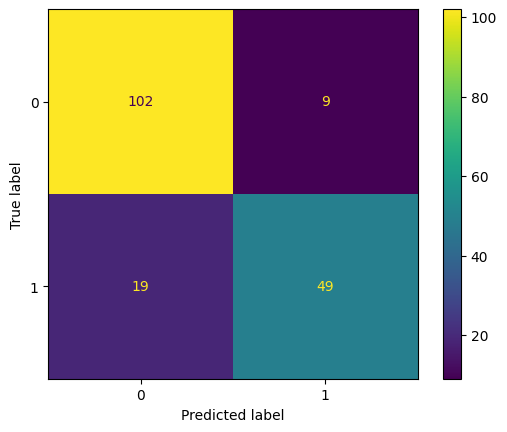

In [9]:
cat_mat = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cat_mat).plot()

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       111
           1       0.84      0.72      0.78        68

    accuracy                           0.84       179
   macro avg       0.84      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179

